# Chile: reconstruct the sample and explore the main DYNAMAP fit

Run all cells from a fresh kernel to reconstruct the Chilean sample, load the supplied weights, and regenerate coordinates, held-out metrics and training curves. **`REFIT = False` performs no training.** Set it to `True` to train for the fixed 20 epochs using the visible code below. Refit mode replaces that fit's outputs, so change `OUTPUT` when exploring another architecture or seed.

**Inputs:** `data/raw/chile_choices.csv`, `chile_cycles.csv` and `chile_bot_predictions.csv`, plus `data/processed/participant_age_decisions.csv` generated by notebook 01. Saved-fit mode also reads `outputs/models/Chile_dim2_seed101/`. All inputs are included, so notebook 01 need not run first.

**Outputs:** the filtered `Chile_pairs.parquet`, split assignments and participant support in `data/processed/`, fitted coordinates and metrics in `outputs/models/`, and sample summaries and training plots in `outputs/diagnostics/` and `outputs/figures/`. These are inputs to notebooks 04, 05 and the figure notebooks.

Age exclusion occurs after the original cleaning rules and before splitting. Missing age is retained. Neither demographics nor ideological self-placement enters estimation. The intermediate choice head favors the closer proposal and complements the probability when A and B are exchanged. Its positive distance multiplier remains flexible, without requiring each probability derivative to be monotone. At two dimensions the current [8, 8] head has 105 parameters, the [3] head has 13, and the original head has 20, excluding coordinate parameters.


In [1]:
from pathlib import Path
import json
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import tensorflow as tf

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."
sys.path.insert(0, str(ROOT / "src"))
from choice_models import build_choice_model

assert tf.__version__.startswith(
    "2.15."
), "Use TensorFlow 2.15, as specified in requirements.txt."
RAW = ROOT / "data/raw"
PROCESSED = ROOT / "data/processed"
OUTPUT = ROOT / "outputs"
for folder in [
    PROCESSED,
    OUTPUT / "models",
    OUTPUT / "diagnostics",
    OUTPUT / "figures",
    OUTPUT / "tables",
]:
    folder.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

# False reloads the included manuscript fit. True trains a new fit and replaces
# its weights, coordinates and history in OUTPUT. Change OUTPUT to keep experiments separate.
REFIT = False
VARIANT = "intermediate"  # "original" selects the fully flexible head.
HIDDEN_SIZES = [8, 8]  # [3] selects the compact 13-parameter intermediate head.
MINIMUM_SCALE = 1e-6  # Positive floor for the intermediate distance multiplier.
MODEL_SETTINGS = dict(variant=VARIANT, hidden_sizes=HIDDEN_SIZES, minimum_scale=MINIMUM_SCALE)
EPOCHS = 20  # Always use the final epoch, not the best held-out epoch.
BATCH_SIZE = 64
LEARNING_RATE = 0.01  # Adamax learning rate.
STEPS_PER_EXECUTION = 64  # Groups graph execution calls, not optimizer updates.
DEVICE = "/CPU:0"

DIMENSION = 2
SEED = 101
RUN_NAME = f"Chile_dim{DIMENSION}_seed{SEED}"
RUN = OUTPUT / "models" / RUN_NAME
RUN.mkdir(parents=True, exist_ok=True)


## Reconstruct the historical first-cycle sample

Keep proposal pairs from cycle 1 and timestamps in the half-open interval
2019-10-24 11:35:05 to 2019-10-31 01:35:54. As in the historical notebook, the
minimum of 10 records is checked before duplicate-pair, bot, and skipped-choice
removal. Retain the latest observation of each unordered pair per participant,
join the original bot labels, retain `prediction == 0`, and exclude `selected == 0`.
These rules must reproduce 3,007,714 records, 48,119 participants, and 90 proposals
before the newly requested age exclusion.

In [2]:
cycle_membership = pd.read_csv(RAW / "chile_cycles.csv")
cycle_proposals = cycle_membership.loc[cycle_membership["cycle_1"].eq(1), "id"]
columns = ["id", "uuid", "option_a", "option_b", "selected", "datetime"]
# Read the large source file in blocks, retaining only the first cycle.
cycle_blocks = []
raw_record_count = 0
for block in pd.read_csv(RAW / "chile_choices.csv", usecols=columns, chunksize=500_000):
    raw_record_count += len(block)
    block["datetime"] = pd.to_datetime(block["datetime"].str[:19], format="%Y-%m-%d %H:%M:%S")
    in_cycle = (
        block["datetime"].ge("2019-10-24 11:35:05")
        & block["datetime"].lt("2019-10-31 01:35:54")
        & block["option_a"].isin(cycle_proposals)
        & block["option_b"].isin(cycle_proposals)
    )
    cycle_blocks.append(block.loc[in_cycle])
pairs = pd.concat(cycle_blocks, ignore_index=True).sort_values("datetime")
del cycle_blocks
sample_flow = [
    {"stage": "all source records", "records": raw_record_count, "participants": pd.NA},
    {"stage": "cycle 1", "records": len(pairs), "participants": pairs["uuid"].nunique()},
]

pairs = pairs.dropna(subset=["option_a", "option_b"]).reset_index(drop=True)
pairs[["option_a", "option_b", "selected"]] = pairs[
    ["option_a", "option_b", "selected"]
].astype(int)
participant_counts = pairs.groupby("uuid")["id"].count()
pairs = pairs[pairs["uuid"].isin(participant_counts.index[participant_counts.ge(10)])].copy()
sample_flow.append(
    {
        "stage": "at least 10 original cycle records",
        "records": len(pairs),
        "participants": pairs["uuid"].nunique(),
    }
)

# Sorting each pair makes A–B and B–A the same question for deduplication.
pairs["option_low"] = pairs[["option_a", "option_b"]].min(axis=1)
pairs["option_high"] = pairs[["option_a", "option_b"]].max(axis=1)
pairs = pairs.sort_values(["id", "datetime"])
last_pair = pairs[["uuid", "option_low", "option_high", "datetime", "id"]]
# Preserve the original tie/order handling when choosing the last record.
last_pair = (
    last_pair.groupby(["datetime", "uuid", "option_low", "option_high", "id"])
    .size()
    .reset_index(name="count")
)
last_pair = last_pair.drop_duplicates(["uuid", "option_low", "option_high"], keep="last")
pairs = pairs[pairs["id"].isin(last_pair["id"])].copy()
sample_flow.append(
    {
        "stage": "latest unordered pair per participant",
        "records": len(pairs),
        "participants": pairs["uuid"].nunique(),
    }
)

bot_flags = pd.read_csv(RAW / "chile_bot_predictions.csv", usecols=["uuid", "prediction"])
assert bot_flags["uuid"].is_unique
pairs = pairs.merge(bot_flags, on="uuid", how="inner", validate="many_to_one")
pairs = pairs[pairs["prediction"].eq(0) & pairs["selected"].ne(0) & pairs["uuid"].notna()]
pairs = pairs[columns].copy()
assert len(pairs) == 3_007_714
assert pairs["uuid"].nunique() == 48_119
assert len(set(pairs["option_a"]) | set(pairs["option_b"])) == 90
assert pairs["id"].is_unique
assert (pairs["selected"].eq(pairs["option_a"]) | pairs["selected"].eq(pairs["option_b"])).all()
sample_flow.append(
    {
        "stage": "historical analysis sample",
        "records": len(pairs),
        "participants": pairs["uuid"].nunique(),
    }
)

historical_sample = pd.DataFrame(sample_flow)
display(historical_sample)
historical_sample.to_csv(
    OUTPUT / "diagnostics" / "Chile_historical_sample_flow.csv", index=False
)
historical_sample.to_latex(
    OUTPUT / "diagnostics" / "Chile_historical_sample_flow.tex", index=False
)


,stage,records,participants
0,all source records,7625476,<NA>
1,cycle 1,3656608,63732
2,at least 10 original cycle records,3613653,50061
3,latest unordered pair per participant,3494211,50061
4,historical analysis sample,3007714,48119


## Apply the common participant-level age decisions

Missing age and absent demographic records are valid retention statuses. An ID
absent from the age decision table is retained as having no reported age. Any
participant marked for exclusion loses all
their comparisons. The threshold and treatment of conflicting/invalid values are
defined in the upstream age-decision notebook and are not reinterpreted here.

In [3]:
age_decisions = pd.read_csv(
    PROCESSED / "participant_age_decisions.csv", dtype={"uuid": "string"}
)
age_decisions = age_decisions[age_decisions["country"].eq("Chile")].copy()
assert age_decisions["uuid"].is_unique
assert {"uuid", "include", "status", "age"}.issubset(age_decisions.columns)
include_codes = (
    age_decisions["include"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False, "1": True, "0": False})
)
assert include_codes.notna().all(), "Include decisions must be true/false or 1/0."
age_decisions["include"] = include_codes.astype(bool)
excluded_ids = set(age_decisions.loc[~age_decisions["include"], "uuid"])
pair_counts = pairs.groupby("uuid").size().rename("records")
age_audit = pair_counts.reset_index().merge(
    age_decisions, on="uuid", how="left", validate="one_to_one"
)
age_audit["include"] = age_audit["include"].fillna(True).astype(bool)
age_audit["status"] = age_audit["status"].fillna("missing_age_no_metadata")
age_summary = (
    age_audit.groupby(["include", "status"], dropna=False)
    .agg(participants=("uuid", "size"), records=("records", "sum"))
    .reset_index()
)
display(age_summary)
age_summary.to_csv(OUTPUT / "diagnostics" / "Chile_age_exclusion_summary.csv", index=False)
age_summary.to_latex(OUTPUT / "diagnostics" / "Chile_age_exclusion_summary.tex", index=False)

pairs = pairs[~pairs["uuid"].isin(excluded_ids)].copy()
assert not set(pairs["uuid"]) & excluded_ids
assert len(set(pairs["option_a"]) | set(pairs["option_b"])) == 90
sample_flow.append(
    {
        "stage": "after participant age exclusion",
        "records": len(pairs),
        "participants": pairs["uuid"].nunique(),
    }
)
sample_flow = pd.DataFrame(sample_flow)
display(sample_flow)
sample_flow.to_csv(OUTPUT / "diagnostics" / "Chile_sample_flow.csv", index=False)
sample_flow.to_latex(OUTPUT / "diagnostics" / "Chile_sample_flow.tex", index=False)
display(pairs)
pairs.to_parquet(PROCESSED / "Chile_pairs.parquet", index=False)


,include,status,participants,records
0,False,below_age_cutoff,395,21029
1,False,conflicting_age,88,12386
2,False,invalid_age,62,3952
3,True,eligible_reported_age,37636,2664674
4,True,unknown_age_retained,9938,305673


,stage,records,participants
0,all source records,7625476,<NA>
1,cycle 1,3656608,63732
2,at least 10 original cycle records,3613653,50061
3,latest unordered pair per participant,3494211,50061
4,historical analysis sample,3007714,48119
5,after participant age exclusion,2970347,47574


,id,uuid,option_a,option_b,selected,datetime
0,5,8bd42737-b140-4db8-af4c-59839922129a,33,20,33,2019-10-24 11:40:24
1,6,8bd42737-b140-4db8-af4c-59839922129a,85,7,85,2019-10-24 11:41:33
2,7,8bd42737-b140-4db8-af4c-59839922129a,41,13,13,2019-10-24 11:41:36
3,8,8bd42737-b140-4db8-af4c-59839922129a,81,46,46,2019-10-24 11:41:41
4,10,8bd42737-b140-4db8-af4c-59839922129a,35,41,35,2019-10-24 11:44:16
...,...,...,...,...,...,...
3494203,3674844,3ddc9eae-ba7b-4dab-8e43-5c188daf9692,82,53,53,2019-10-31 01:35:42
3494205,3674847,3ddc9eae-ba7b-4dab-8e43-5c188daf9692,85,15,85,2019-10-31 01:35:47
3494208,3674850,3ddc9eae-ba7b-4dab-8e43-5c188daf9692,17,74,17,2019-10-31 01:35:50
3494209,3674851,2e8f5550-d794-411c-b36e-d277e88f5d30,79,16,79,2019-10-31 01:35:51


## Split within participants while retaining at least one training choice

For participants with at least two usable choices, the first `floor(0.9 * n)`
observations are training records and the remainder are held out. The original notebook left its within-participant
shuffle commented out. Records therefore retain their original `id, datetime`
ordering. Training records are subsequently shuffled each epoch. IDs are mapped
in sorted order; the input columns are proposal A, participant, proposal B, and
the response is one exactly when the participant selected proposal A.

The historical minimum of 10 precedes cleaning, so some participants can have
only one usable choice left. This notebook assigns that choice to training and
none to the test set, so every exported participant coordinate is informed by at
least one choice. This is an explicit correction to the historical split; it
does not remove any additional participant.

In [4]:
ordered = pairs.sort_values(["uuid", "id", "datetime"], kind="mergesort").reset_index(drop=True)
users = np.array(sorted(ordered["uuid"].unique()))
options = np.array(sorted(set(ordered["option_a"]) | set(ordered["option_b"])))
user_index = {uuid: index for index, uuid in enumerate(users)}
option_index = {option: index for index, option in enumerate(options)}
# Inputs are integer lookup indices, not age, self-placement or policy features.
X_all = np.column_stack(
    [
        ordered["option_a"].map(option_index),
        ordered["uuid"].map(user_index),
        ordered["option_b"].map(option_index),
    ]
).astype(np.int32)
y_all = ordered["selected"].eq(ordered["option_a"]).to_numpy(dtype=np.int32)
within_user_index = ordered.groupby("uuid", sort=False).cumcount().to_numpy()
within_user_count = ordered.groupby("uuid", sort=False)["id"].transform("size").to_numpy()
# Every participant gets at least one training row, including singletons.
training_count = np.maximum(1, np.floor(within_user_count * (1 - 0.1)).astype(int))
is_training = within_user_index < training_count
X_train, y_train = X_all[is_training], y_all[is_training]
X_test, y_test = X_all[~is_training], y_all[~is_training]
assert set(X_train[:, 1]) == set(range(len(users)))
assert set(X_test[:, 1]).issubset(set(X_train[:, 1]))
assert not set(ordered.loc[is_training, "id"]) & set(ordered.loc[~is_training, "id"])
split_assignments = ordered[["id", "uuid"]].copy()
split_assignments["split"] = np.where(is_training, "train", "test")
display(split_assignments)
split_assignments.to_parquet(PROCESSED / "Chile_split_assignments.parquet", index=False)
split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "records": len(y_train),
            "participants": len(np.unique(X_train[:, 1])),
            "used_per_epoch": len(y_train),
        },
        {
            "split": "test",
            "records": len(y_test),
            "participants": len(np.unique(X_test[:, 1])),
            "used_per_epoch": len(y_test),
        },
    ]
)
display(split_summary)
split_summary.to_csv(OUTPUT / "diagnostics" / "Chile_split_summary.csv", index=False)
split_summary.to_latex(OUTPUT / "diagnostics" / "Chile_split_summary.tex", index=False)
participant_support = ordered.groupby("uuid").size().rename("total_choices").reset_index()
training_support = ordered.loc[is_training].groupby("uuid").size().rename("training_choices")
participant_support = participant_support.merge(training_support, on="uuid", how="left")
participant_support["training_choices"] = (
    participant_support["training_choices"].fillna(0).astype(int)
)
assert participant_support["training_choices"].ge(1).all()
display(participant_support)
participant_support.to_csv(PROCESSED / "Chile_participant_support.csv", index=False)
singleton_summary = pd.DataFrame(
    [
        {
            "participants_with_one_choice": int(
                participant_support["total_choices"].eq(1).sum()
            ),
            "participants_without_training_choices": int(
                participant_support["training_choices"].eq(0).sum()
            ),
        }
    ]
)
display(singleton_summary)
singleton_summary.to_csv(OUTPUT / "diagnostics" / "Chile_singleton_summary.csv", index=False)
singleton_summary.to_latex(OUTPUT / "diagnostics" / "Chile_singleton_summary.tex", index=False)


,id,uuid,split
0,714773,000057c7-295c-4a61-8f62-76aff62bf079,train
1,714901,000057c7-295c-4a61-8f62-76aff62bf079,train
2,714979,000057c7-295c-4a61-8f62-76aff62bf079,train
3,715159,000057c7-295c-4a61-8f62-76aff62bf079,train
4,715220,000057c7-295c-4a61-8f62-76aff62bf079,train
...,...,...,...
2970342,1373535,fffefb08-5a73-45eb-83c4-5a02eb64a0d6,train
2970343,1373642,fffefb08-5a73-45eb-83c4-5a02eb64a0d6,train
2970344,1373733,fffefb08-5a73-45eb-83c4-5a02eb64a0d6,test
2970345,1373909,fffefb08-5a73-45eb-83c4-5a02eb64a0d6,test


,split,records,participants,used_per_epoch
0,train,2650103,47574,2650103
1,test,320244,47566,320244


,uuid,total_choices,training_choices
0,000057c7-295c-4a61-8f62-76aff62bf079,38,34
1,000059b8-10b9-4f74-9c01-80bd2c48f509,184,165
2,00032199-2183-48c0-8f0d-ac37dc8ece60,157,141
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,21,18
4,0006b923-77a6-40c1-95e0-f98b817bcab2,21,18
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,27,24
47570,fffa9813-765b-46c6-87f6-47fa854e784f,40,36
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,94,84
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,40,36


,participants_with_one_choice,participants_without_training_choices
0,8,0


## Load the supplied fit or train a new one

The requested model is first constructed from the parameters above. In saved-fit mode its complete specification must match the included specification before weights are loaded. This prevents changing an architecture or seed and accidentally labeling the old fit as a new one. Training settings affect only `REFIT = True`.

The original training procedure uses Adamax, binary cross-entropy and shuffled training batches. The smaller final batch is retained in training and evaluation. `steps_per_execution` reduces Python overhead without changing minibatches. The final epoch is fixed in advance. Held-out values do not select the checkpoint.

Only a new training run collects coordinate snapshots at initialization and epochs 5, 10 and 20. Saved-fit mode leaves the supplied snapshots intact and uses the supplied training history to redraw its historical curves. It never substitutes a newly initialized map for a historical snapshot.


### Construct the model

The shared source files contain the reusable coordinate layer and choice function. The table lists the actual trainable tensors. Embedding parameters grow with the number of participants and proposals, while the head parameters do not.

In [5]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = (
    train_dataset.shuffle(len(y_train)).batch(BATCH_SIZE, drop_remainder=False).repeat()
)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE, drop_remainder=False).repeat()

with tf.device(DEVICE):
    model = build_choice_model(len(options), len(users), DIMENSION, SEED, **MODEL_SETTINGS)
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=["accuracy"],
        steps_per_execution=STEPS_PER_EXECUTION,
    )

# Check fit identity before any model-derived output can be overwritten.
model_specification = json.loads(model.choice_configuration_json)
if not REFIT:
    saved_specification = json.loads((RUN / "model_specification.json").read_text())
    assert (
        model_specification == saved_specification
    ), "Requested model differs from the supplied fit. Use REFIT=True."
    # Sorted IDs define the meaning of each embedding row, not just its shape.
    assert pd.read_csv(RUN / "coordsU.csv")["uuid"].tolist() == users.tolist()
    assert pd.read_csv(RUN / "coordsP.csv")["id"].tolist() == options.tolist()
    model.load_weights(str(RUN / "model.weights.h5"))

parameter_table = pd.DataFrame(
    [
        {
            "tensor": variable.name,
            "shape": str(tuple(variable.shape)),
            "parameters": int(np.prod(variable.shape)),
        }
        for variable in model.trainable_variables
    ]
)
display(parameter_table)
parameter_table.to_csv(RUN / "trainable_parameters.csv", index=False)
parameter_table.to_latex(RUN / "trainable_parameters.tex", index=False)


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 2)",180
1,participant_coordinates:0,"(47574, 2)",95148
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


Loaded the supplied fit. Curves and fit duration describe its original training.


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.610236,0.665072,0.611114,0.664806
1,2,0.589495,0.684641,0.597038,0.680313
2,3,0.571627,0.700570,0.589006,0.686230
3,4,0.562798,0.707414,0.584372,0.689353
4,5,0.558853,0.710255,0.584209,0.689268
5,6,0.556674,0.712011,0.583044,0.689787
6,7,0.555557,0.712960,0.586063,0.689178
7,8,0.555012,0.713375,0.585880,0.688947
8,9,0.554830,0.713529,0.590195,0.687716
9,10,0.554812,0.713610,0.588780,0.687454


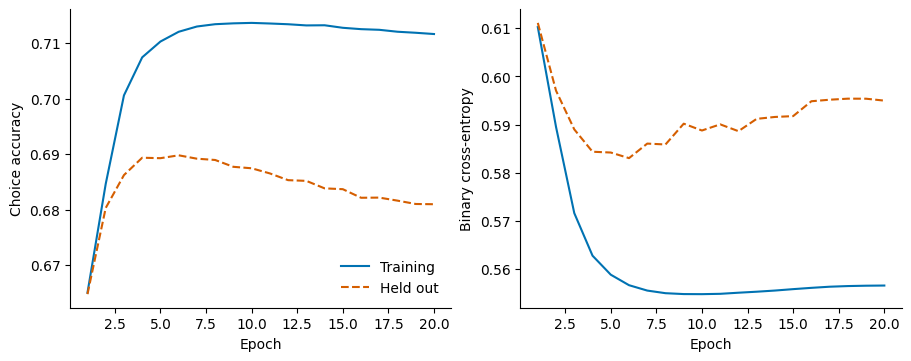

In [6]:
class CoordinateSnapshots(tf.keras.callbacks.Callback):
    # No file writes are hidden inside the callback: collect live arrays only.
    def __init__(self):
        super().__init__()
        self.coordinates = {}

    def on_train_begin(self, logs=None):
        self.coordinates[0] = (
            self.model.layers[0].returnUsersEmbedding().numpy().copy(),
            self.model.layers[0].returnOptionsEmbedding().numpy().copy(),
        )

    def on_epoch_end(self, epoch, logs=None):
        if epoch + 1 in {5, 10, 20, EPOCHS}:
            self.coordinates[epoch + 1] = (
                self.model.layers[0].returnUsersEmbedding().numpy().copy(),
                self.model.layers[0].returnOptionsEmbedding().numpy().copy(),
            )


if REFIT:
    snapshots = CoordinateSnapshots()
    started = time.perf_counter()
    with tf.device(DEVICE):
        history = model.fit(
            train_dataset,
            epochs=EPOCHS,
            steps_per_epoch=int(np.ceil(len(y_train) / BATCH_SIZE)),
            validation_data=test_dataset,
            validation_steps=int(np.ceil(len(y_test) / BATCH_SIZE)),
            callbacks=[snapshots],
            verbose=2,
        )
    elapsed_seconds = time.perf_counter() - started
    history_table = pd.DataFrame(history.history)
    history_table.insert(0, "epoch", np.arange(1, len(history_table) + 1))
else:
    history_table = pd.read_csv(RUN / "history.csv")
    elapsed_seconds = float(pd.read_csv(RUN / "metrics.csv").iloc[0]["seconds"])
    print("Loaded the supplied fit. Curves and fit duration describe its original training.")
assert np.isfinite(history_table.select_dtypes("number")).all().all()
display(history_table)
history_table.to_csv(RUN / "history.csv", index=False)
history_table.to_latex(RUN / "history.tex", index=False)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")
for axis, metric, label in zip(
    axes, ["accuracy", "loss"], ["Choice accuracy", "Binary cross-entropy"]
):
    axis.plot(history_table["epoch"], history_table[metric], color="#0072B2", label="Training")
    axis.plot(
        history_table["epoch"],
        history_table[f"val_{metric}"],
        color="#D55E00",
        linestyle="--",
        label="Held out",
    )
    axis.set(xlabel="Epoch", ylabel=label)
    axis.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
display(fig)
fig.savefig(OUTPUT / "figures" / f"{RUN_NAME}_training.pdf", bbox_inches="tight")
plt.close(fig)


## Evaluate choices and regenerate coordinates

Every held-out record is evaluated once with the final model. Coordinates are extracted from the loaded or newly trained embedding matrices and joined to the same sorted IDs used to build the inputs. The duration is training time, preserved from the supplied fit in saved-fit mode.

In [7]:
with tf.device(DEVICE):
    full_test_metrics = model.evaluate(
        X_test, y_test, batch_size=BATCH_SIZE, verbose=0, return_dict=True
    )
metrics = pd.DataFrame(
    [
        {
            "country": "Chile",
            "dimension": DIMENSION,
            "seed": SEED,
            "participants": len(users),
            "proposals": len(options),
            "records": len(ordered),
            "training_records": len(y_train),
            "test_records": len(y_test),
            "test_loss_all_records": full_test_metrics["loss"],
            "test_accuracy_all_records": full_test_metrics["accuracy"],
            "last_epoch_test_accuracy": history_table.iloc[-1]["val_accuracy"],
            "singleton_participants_assigned_to_train": int(
                participant_support["total_choices"].eq(1).sum()
            ),
            "seconds": elapsed_seconds,
        }
    ]
)
display(metrics)
metrics.to_csv(RUN / "metrics.csv", index=False)
metrics.to_latex(RUN / "metrics.tex", index=False)

coordinate_columns = [f"z{i + 1}" for i in range(DIMENSION)]
participant_coordinates = pd.DataFrame(
    model.layers[0].returnUsersEmbedding().numpy(), columns=coordinate_columns
)
participant_coordinates.insert(0, "uuid", users)
proposal_coordinates = pd.DataFrame(
    model.layers[0].returnOptionsEmbedding().numpy(), columns=coordinate_columns
)
proposal_coordinates.insert(0, "id", options)
assert not set(participant_coordinates["uuid"]) & excluded_ids
for coordinates, filename in [
    (participant_coordinates, "coordsU.csv"),
    (proposal_coordinates, "coordsP.csv"),
]:
    assert np.isfinite(coordinates[coordinate_columns]).all().all()
    display(coordinates)
    coordinates.to_csv(RUN / filename, index=False)

if REFIT:
    # Remove snapshots left by another epoch schedule only after fitting succeeds.
    # This keeps an old epoch-20 map from being mistaken for a new 10-epoch fit.
    for stale_snapshot in list(RUN.glob("coordsU_epoch_*.csv")) + list(
        RUN.glob("coordsP_epoch_*.csv")
    ):
        stale_snapshot.unlink()
    # These epoch coordinates exist only after this model has actually trained.
    for epoch, (participant_array, proposal_array) in snapshots.coordinates.items():
        epoch_users = pd.DataFrame(participant_array, columns=coordinate_columns)
        epoch_users.insert(0, "uuid", users)
        epoch_proposals = pd.DataFrame(proposal_array, columns=coordinate_columns)
        epoch_proposals.insert(0, "id", options)
        display(epoch_users)
        epoch_users.to_csv(RUN / f"coordsU_epoch_{epoch}.csv", index=False)
        display(epoch_proposals)
        epoch_proposals.to_csv(RUN / f"coordsP_epoch_{epoch}.csv", index=False)

model.summary()
display(model_specification)
if REFIT:
    model.save_weights(str(RUN / "model.weights.h5"))
    (RUN / "model_specification.json").write_text(
        json.dumps(model_specification, indent=2) + "\n"
    )
    run_properties = {
        "country": "Chile",
        "dimension": DIMENSION,
        "seed": SEED,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "steps_per_execution": STEPS_PER_EXECUTION,
        "device": DEVICE,
        "architecture": VARIANT,
        "model_configuration": MODEL_SETTINGS,
        "checkpoint_selection": "fixed_final_epoch",
        "tensorflow_version": tf.__version__,
        "participants": len(users),
        "proposals": len(options),
        "included_missing_age": True,
        "singleton_choice_assigned_to_train": True,
        "drop_remainder": False,
    }
    display(run_properties)
    (RUN / "properties.json").write_text(json.dumps(run_properties, indent=2) + "\n")


,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,101,47574,90,2970347,2650103,320244,0.594979,0.680987,0.680987,8,633.565454


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.620236,0.677677
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.371590,0.204995
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.143278,0.733773
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.287662,0.412808
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.262506,0.210308
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.218051,0.444988
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.736183,0.269224
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.278650,0.946591
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.296505,0.188945


,id,z1,z2
0,1,0.663117,0.460457
1,2,0.977909,0.769293
2,3,0.331054,0.274275
3,4,0.545465,0.685188
4,5,0.739270,0.115391
...,...,...,...
85,86,0.381413,0.672768
86,87,0.370188,0.254616
87,88,0.350024,0.830478
88,89,0.293969,0.046756


Model: "dynamap_intermediate"


_________________________________________________________________


...

Total params: 95433 (372.79 KB)


Trainable params: 95433 (372.79 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


{'dimension': 2,
 'embedding_seed': 101,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 101,
 'variant': 'intermediate'}